# Część - Bootstrapowy przedział ufności i wykrywanie ataku DDoS
Kod notatnika bazuje na kodzie  `boostrapik.py`.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from boostrapik import generate_data, bootstrap_ci, detect_global_anomalies, rolling_bootstrap_anomalies, RESULTS_DIR
plt.rcParams['figure.figsize'] = (10,4)

## Generowanie danych
Użyto rozkładu normalnego o parametrach:
- średnia - `loc=500`,
-  standardowe - `scale=30`,
- wartości ataku - `3000-8000`,

W wyniku tego otrzymano próbkę ruchu.

In [2]:
normal_rps, ddos_rps, combined = generate_data()
n_normal = len(normal_rps)
print('Liczba punktów normalnych:', n_normal)
print('Przykładowe wartości ataku:', ddos_rps)
pd.Series(normal_rps).describe()

Liczba punktów normalnych: 360
Przykładowe wartości ataku: [3000 4500 7200 8000 6000 5500 4000 3500]


count    360.000000
mean     499.031518
std       30.286108
min      386.831745
25%      479.727287
50%      498.506649
75%      519.240939
max      591.981102
dtype: float64

## Eksperyment - wpływ poziomu istotności (α)
Obliczymy górne granice bootstrapowego przedziału ufności dla kilku wartości α oraz policzymy liczbę wykrytych anomalii. Dla wykrywania anomalii tylko na ddos_rps dostajemy zawsze 8 anomalii. Większy sens ma więc sprawdzanie całego sygnału - wyniki ukazano w tabeli poniżej.

In [3]:
alphas = [0.1, 0.05, 0.01, 0.001]
rows = []
for alpha in alphas:
    lower, upper, stats = bootstrap_ci(normal_rps, stat_func=np.mean, n_bootstrap=2000, alpha=alpha, seed=1)
    anomalies_global = [i for i, r in enumerate(combined) if r > upper]
    rows.append({'alpha': alpha, 'upper': float(upper), 'anomalies_total': len(anomalies_global)})
df_alpha = pd.DataFrame(rows)
df_alpha

,alpha,upper,anomalies_total
0,0.100,501.640049,173
1,0.050,502.130573,171
2,0.010,503.077995,167
3,0.001,504.085441,162


Poniżej ukazano histogramy rozkładu bootstrapowych statystyk dla α=0.05 i α=0.001 (przykładowo).

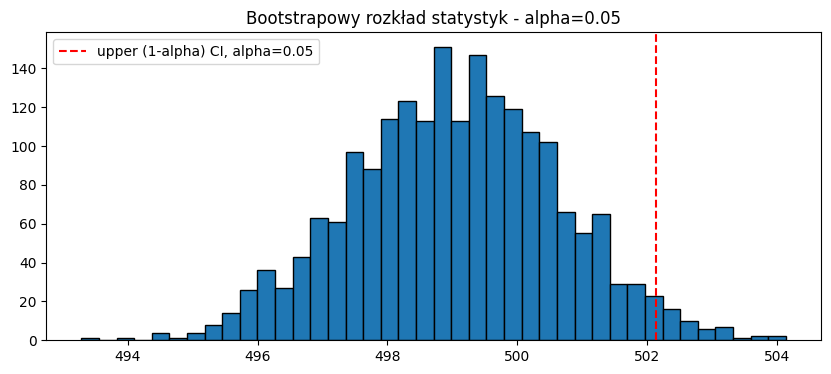

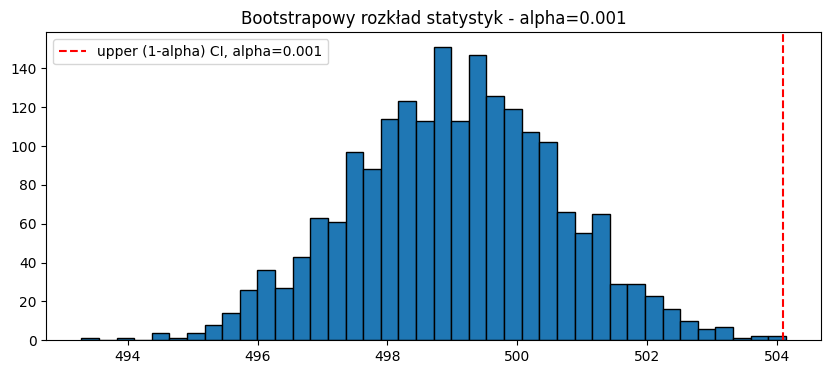

In [9]:
for alpha in [0.05, 0.001]:
    _, upper, stats = bootstrap_ci(normal_rps, stat_func=np.mean, n_bootstrap=2000, alpha=alpha, seed=1)
    plt.figure()
    plt.hist(stats, bins=40, edgecolor='black')
    plt.axvline(upper, color='red', linestyle='--', label=f'upper (1-alpha) CI, alpha={alpha}')
    plt.legend()
    plt.title(f'Bootstrapowy rozkład statystyk - alpha={alpha}')
    plt.show()

Widać, że zmniejszenie poziomu istotności powoduje rozszerzenie przedziału ufności, co prowadzi do wzrostu progu detekcji anomalii. W efekcie liczba wykrytych anomalii w całym sygnale maleje (i odwrotnie).

## Eksperyment - wpływ statystyki (mean, median, p90)
Porównano progi i liczbę wykrytych anomalii dla różnych funkcji statystycznych (dla α=0.05).

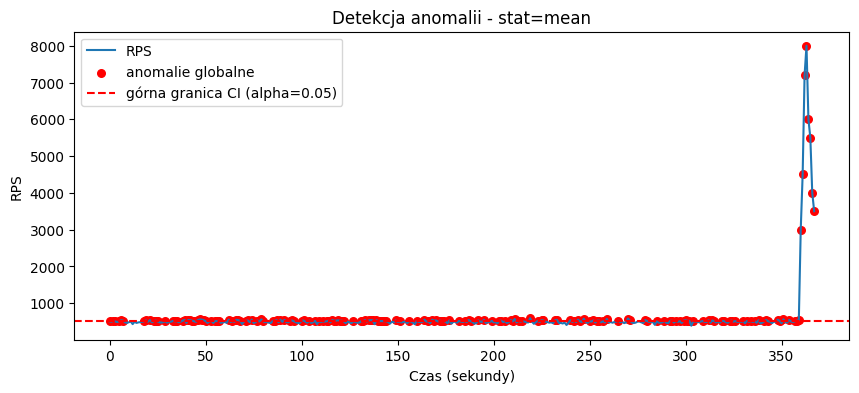

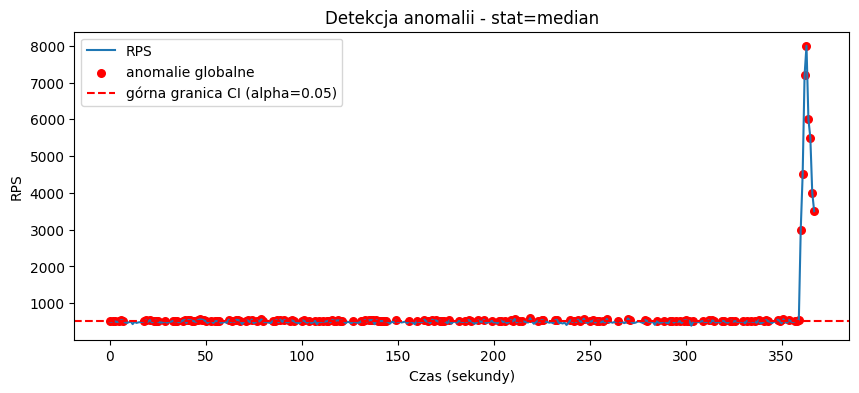

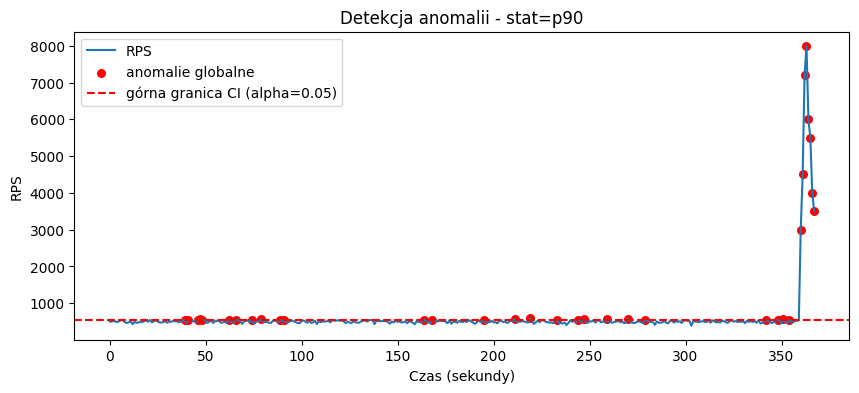

,stat,upper,anomalies_total,anomalies_in_attack
0,mean,502.130573,171,8
1,median,502.544272,169,8
2,p90,542.633650,34,8


In [11]:
stat_funcs = [('mean', np.mean), ('median', np.median), ('p90', lambda x: np.percentile(x,90))]
rows = []
alpha = 0.05
for name, func in stat_funcs:
    lower, upper, stats = bootstrap_ci(normal_rps, stat_func=func, n_bootstrap=2000, alpha=alpha, seed=1)
    anomalies_global = [i for i, r in enumerate(combined) if r > upper]
    anomalies_in_attack = [i for i in anomalies_global if i >= n_normal]
    rows.append({'stat': name, 'upper': float(upper), 'anomalies_total': len(anomalies_global), 'anomalies_in_attack': len(anomalies_in_attack)})
    plt.figure()
    plt.plot(combined, label='RPS')
    if anomalies_global:
        plt.scatter(anomalies_global, [combined[i] for i in anomalies_global], color='red', s=30, label='anomalie globalne')
    plt.axhline(upper, color='red', linestyle='--', label=f'górna granica CI (alpha={alpha})')
    plt.title(f'Detekcja anomalii - stat={name}')
    plt.xlabel('Czas (sekundy)')
    plt.ylabel('RPS')
    plt.legend()
    plt.show()
pd.DataFrame(rows)

Średnia i mediana dają bardzo podobne wyniki, co wynika z symetrycznego charakteru rozkładu normalnego. Zastosowanie 90-tego percentyla powoduje zwiększenie progu detekcji, co zmniejsza liczbę wykrywanych anomalii. Na powyższych wykresach widać różnicę w ilości wykrytych anomalii pomiędzy średnią, medianą i 90-tym percentylem.

## Eksperyment - rolling window
Wykorzystano rolling window (z `rolling_bootstrap_anomalies`, z parametrami `window_size=60`, `step=1`, `n_bootstrap=500`).

mean: Global anomalies=171, Rolling anomalies=129


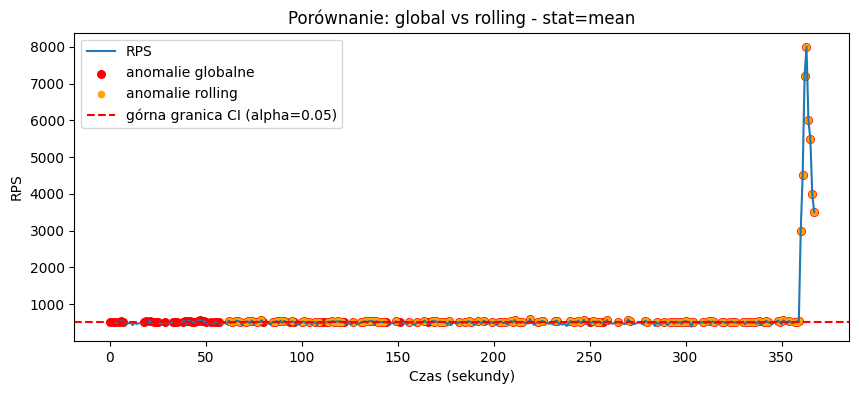

median: Global anomalies=169, Rolling anomalies=117


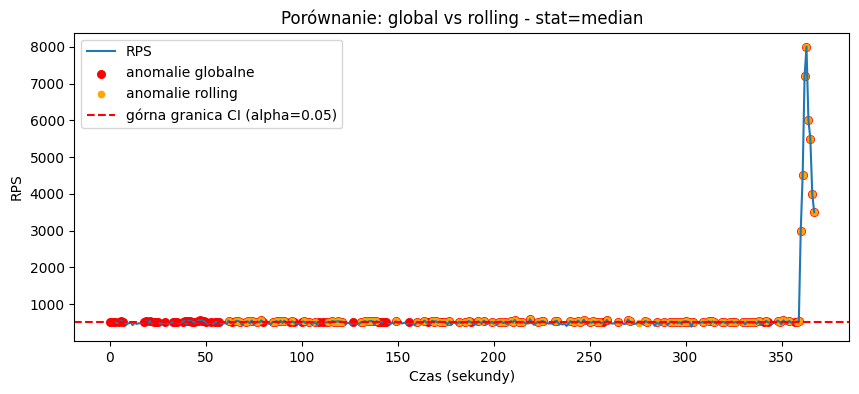

p90: Global anomalies=34, Rolling anomalies=17


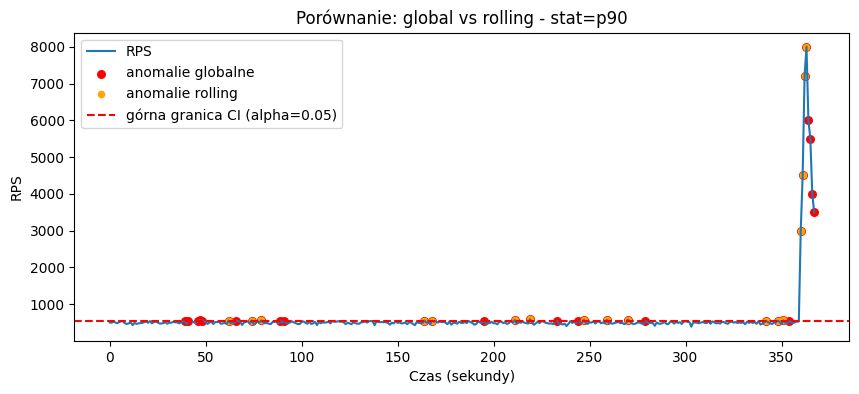

In [13]:
# Rolling window dla kilku statystyk: mean, median, p90
stat_funcs = [('mean', np.mean), ('median', np.median), ('p90', lambda x: np.percentile(x,90))]
window_size = 60
alpha = 0.05
for name, func in stat_funcs:
    rolling_anoms = rolling_bootstrap_anomalies(combined, window_size=window_size, step=1, stat_func=func, n_bootstrap=500, alpha=alpha)
    _, upper, _ = bootstrap_ci(normal_rps, stat_func=func, n_bootstrap=2000, alpha=alpha, seed=1)
    anomalies_global = [i for i, r in enumerate(combined) if r > upper]
    print(f'{name}: Global anomalies={len(anomalies_global)}, Rolling anomalies={len(rolling_anoms)}')
    plt.figure()
    plt.plot(combined, label='RPS')
    if anomalies_global:
        plt.scatter(anomalies_global, [combined[i] for i in anomalies_global], color='red', label='anomalie globalne', s=30)
    if rolling_anoms:
        plt.scatter(rolling_anoms, [combined[i] for i in rolling_anoms], color='orange', label='anomalie rolling', s=20)
    plt.axhline(upper, color='red', linestyle='--', label=f'górna granica CI (alpha={alpha})')
    plt.title(f'Porównanie: global vs rolling - stat={name}')
    plt.xlabel('Czas (sekundy)')
    plt.ylabel('RPS')
    plt.legend()
    plt.show()

Jak widać, okno czasowe redukuje liczbę fałszywych alarmów. Jednak można również zauważyć, że metoda ta w połączeniu z 90-tym percentylem nie działa skutecznie i nie wykrywa wszystkich punktów ataku. Wynika to z charakteru jej działania - okno się przesuwa, zaczyna zawierać wartości ataku, statystyka p90 rośnie więc górna granica przedziału ufności jest zwiększona. W rezultacie kolejne wartości ataku nie przekraczają już wyznaczonego progu i nie są oznaczane jako anomalie.

## Eksperyment - zmiana parametrów generowanego ruchu
Generujemy ruch z `loc=800`, `scale=100` i wartościami ataku w przedziale 1500-2500. Zatem różnica między normalnym ruchem a atakiem jest mniejsza niż w poprzednim eksperymencie. Na wykresach oraz tabelce poniżej przedstawiono rezultaty działania algorytmu dla różnych statystyk, z poziomem istotności równym 0,001.

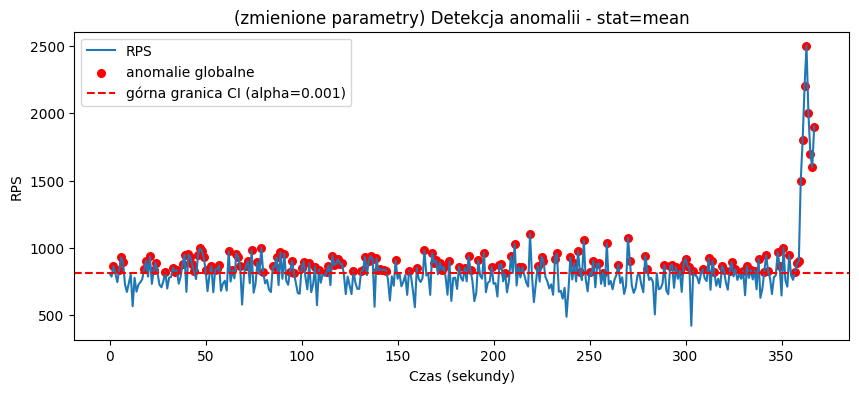

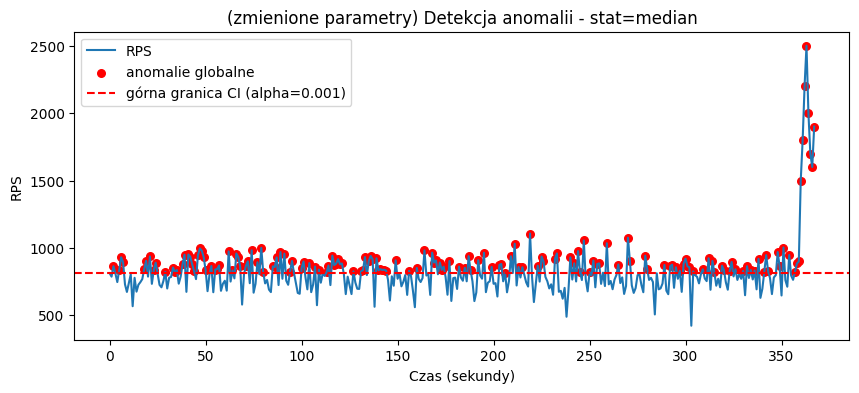

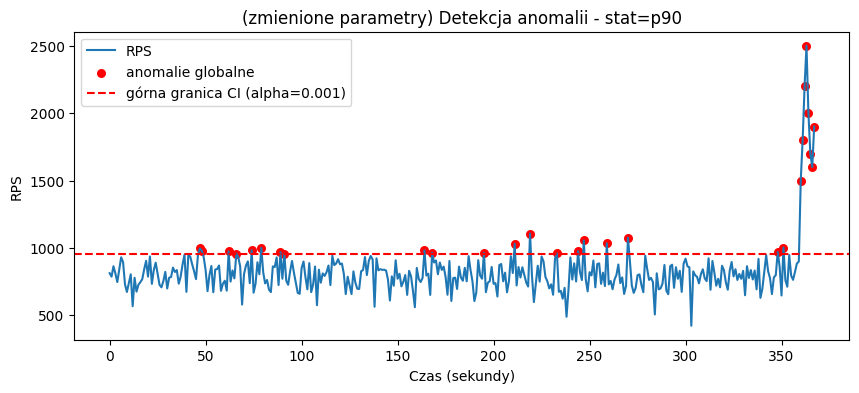

,stat,upper,anomalies_total
0,mean,813.618138,162
1,median,816.325035,160
2,p90,951.392377,28


In [15]:
# Zmienione parametry ruchu: loc=800, scale=100, atak mniejszy
normal2, ddos2, combined2 = generate_data(loc=800, scale=100, normal_size=360, attack_values=[1500,1800,2200,2500,2000,1700,1600,1900], seed=0)
alpha = 0.001
rows = []
stat_funcs = [('mean', np.mean), ('median', np.median), ('p90', lambda x: np.percentile(x,90))]
for name, func in stat_funcs:
    lower2, upper2, stats2 = bootstrap_ci(normal2, stat_func=func, n_bootstrap=2000, alpha=alpha, seed=1)
    anomalies_global2 = [i for i, r in enumerate(combined2) if r > upper2]
    rows.append({'stat': name, 'upper': float(upper2), 'anomalies_total': len(anomalies_global2)})
    plt.figure()
    plt.plot(combined2, label='RPS')
    if anomalies_global2:
        plt.scatter(anomalies_global2, [combined2[i] for i in anomalies_global2], color='red', s=30, label='anomalie globalne')
    plt.axhline(upper2, color='red', linestyle='--', label=f'górna granica CI (alpha={alpha})')
    plt.title(f'(zmienione parametry) Detekcja anomalii - stat={name}')
    plt.xlabel('Czas (sekundy)')
    plt.ylabel('RPS')
    plt.legend()
    plt.show()
pd.DataFrame(rows)

Widać, że zwiększony jest próg istotności, ponieważ jest dostosowany do nowych danych. Metoda nadal wykrywa anomalie.

# Część: Isolation Forest (jednowymiarowe RPS)


In [19]:
# Przygotowanie danych i katalogu wyników dla Isolation Forest
import os
from sklearn.ensemble import IsolationForest
out_dir_if = os.path.join(os.getcwd(), 'isolation_forest_results')
os.makedirs(out_dir_if, exist_ok=True)
# używamy już wygenerowanego "combined" i "normal_rps" z wcześniejszych komórek
X = combined.reshape(-1, 1)
normal_X = normal_rps.reshape(-1, 1)
attack_len = len(ddos_rps)
attack_start = len(combined) - attack_len
print('Długość sygnału:', len(combined), 'dł. ataku:', attack_len)

Długość sygnału: 368 dł. ataku: 8


## Eksperyment - Różne wartości contamination
Parametr contamination określa przybliżony procent punktów danych, które algorytm powinien oznaczyć jako anomalie. Przetestowano cztery wartości contamination, a wyniki przedstawiono w tabeli oraz na wykresach poniżej.

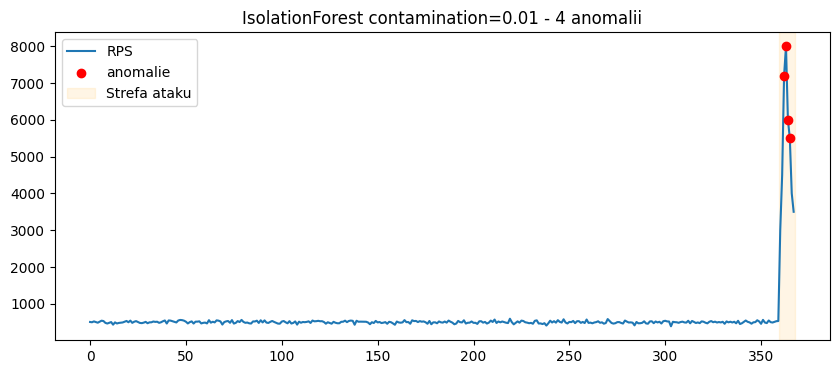

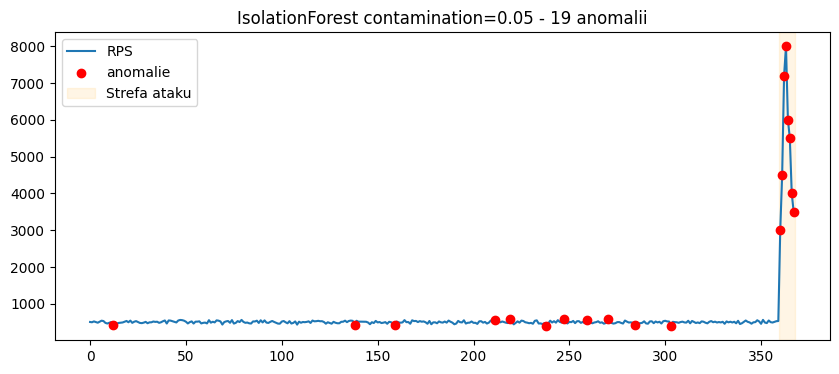

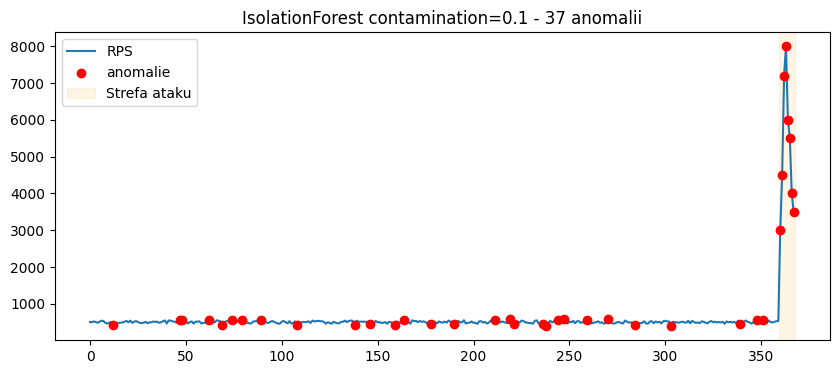

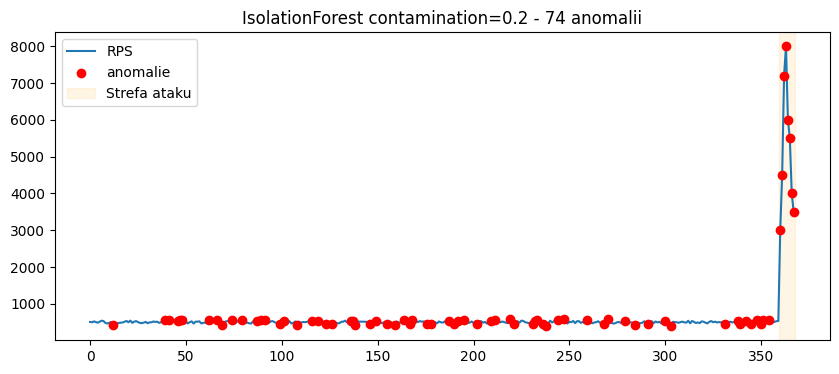

,contamination,num_anomalies
0,0.01,4
1,0.05,19
2,0.10,37
3,0.20,74


In [28]:
contamination_values = [0.01, 0.05, 0.1, 0.2]
contamination_results = {}
rows = []
for c in contamination_values:
    iso = IsolationForest(contamination=c, random_state=0)
    labels = iso.fit_predict(X)  # 1 = normal, -1 = anomaly
    anomaly_indices = np.where(labels == -1)[0]
    contamination_results[c] = anomaly_indices
    rows.append({'contamination': c, 'num_anomalies': int(len(anomaly_indices))})
    
    plt.figure()
    plt.plot(combined, label='RPS')
    if len(anomaly_indices) > 0:
        plt.scatter(anomaly_indices, combined[anomaly_indices], color='red', label='anomalie', zorder=5)
    plt.axvspan(attack_start - 0.5, len(combined) - 0.5, color='orange', alpha=0.1, label='Strefa ataku')
    plt.title(f'IsolationForest contamination={c} - {len(anomaly_indices)} anomalii')
    plt.legend()
    plt.show()

df_cont = pd.DataFrame(rows)

df_cont

Widać wyraźnie, że zwiększenie wartości parametru contamination powoduje wzrost liczby punktów oznaczanych jako anomalie. Dla bardzo małej wartości (0.01) wykrytych zostaje jedynie kilka najbardziej odstających punktów. Natomiast dla większych wartości contamination pojawia się więcej punktów oznaczonych jako anomalie również w części odpowiadającej normalnemu ruchowi, a tym samym wzrasta liczba fałszywych alarmów.

# Eksperyment - uczenie tylko na ruchu normalnym
Parametr `contamination` ustawiono na 0.05 i porównano liczbę wykrytych anomalii dla modelu trenowanego na całym sygnale vs trenowanego wyłącznie na normalnym ruchu.

IF trenowany na normalnym ruchu: liczba anomalii = 26


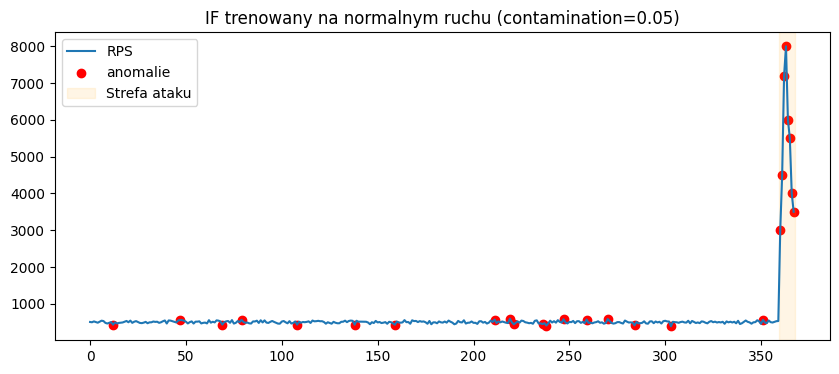

In [32]:
iso_normal_train = IsolationForest(contamination=0.05, random_state=0)
iso_normal_train.fit(normal_X)
labels_trained_on_normal = iso_normal_train.predict(X)
anomaly_idx_normal_train = np.where(labels_trained_on_normal == -1)[0]
print('IF trenowany na normalnym ruchu: liczba anomalii =', len(anomaly_idx_normal_train))
plt.figure()
plt.plot(combined, label='RPS')
if len(anomaly_idx_normal_train)>0:
    plt.scatter(anomaly_idx_normal_train, combined[anomaly_idx_normal_train], color='red', label='anomalie')
plt.axvspan(attack_start - 0.5, len(combined) - 0.5, color='orange', alpha=0.1, label='Strefa ataku')
plt.title('IF trenowany na normalnym ruchu (contamination=0.05)')
plt.legend()
plt.show()

W przypadku uczenia wyłącznie na normalnym ruchu model wykrył większą liczbę anomalii. Wynika to z faktu, że model uczy się wyłącznie wzorca zwykłego zachowania systemu, przez co wszelkie odstępstwa są częściej oznaczane jako anomalie.


## Analiza decision_score
Algorytm Isolation Forest oprócz etykiety anomalii zwraca również wartość decision function, która określa stopień normalności danego punktu danych. Im wyższa wartość score, tym bardziej punkt przypomina normalne dane, natomiast wartości niższe wskazują na potencjalne anomalie.

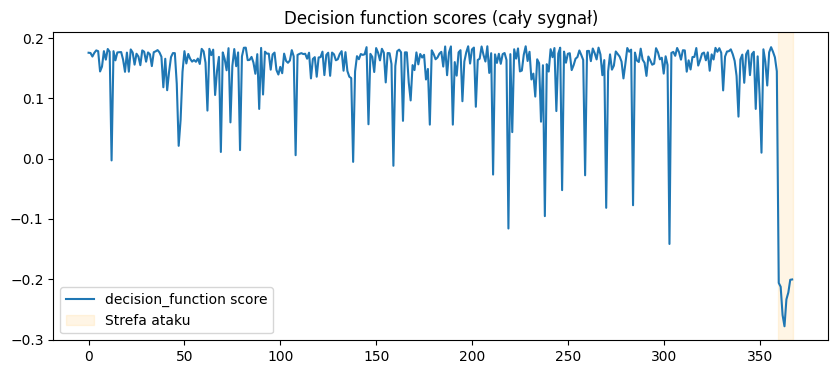

Średni score dla punktów ataku: -0.2265815183852617


In [30]:
iso_for_scores = IsolationForest(contamination=0.05, random_state=0)
iso_for_scores.fit(X)
scores = iso_for_scores.decision_function(X)
plt.figure()
plt.plot(scores, label='decision_function score')
plt.axvspan(attack_start - 0.5, len(combined) - 0.5, color='orange', alpha=0.1, label='Strefa ataku')
plt.title('Decision function scores (cały sygnał)')
plt.legend()
plt.show()
attack_scores = scores[attack_start:]
print('Średni score dla punktów ataku:', float(np.mean(attack_scores)))

Średnia wartość score dla punktów należących do segmentu ataku wyniosła -0.2266.

Ujemna wartość score wskazuje, że punkty te są wyraźnie odseparowane od normalnego rozkładu danych i przez model traktowane jako anomalie. Na powyższym wykresie score’ów można zauważyć wyraźny spadek wartości w końcowej części sygnału odpowiadającej atakowi DDoS.

## Eksperyment - parametry strukturalne modelu
W celu sprawdzenia stabilności działania modelu przeprowadzono eksperyment polegający na zmianie parametrów strukturalnych algorytmu:
- `n_estimators` - liczba drzew w lesie,
- `max_samples` - liczba próbek używanych do budowy pojedynczego drzewa.

Dla każdej konfiguracji wykonano 10 uruchomień modelu z różnymi wartościami ziarna losowego i sprawdzono, które punkty były wykrywane jako anomalie we wszystkich uruchomieniach.

n=50, max_samples=0.5: stabilnie wykrytych = 16


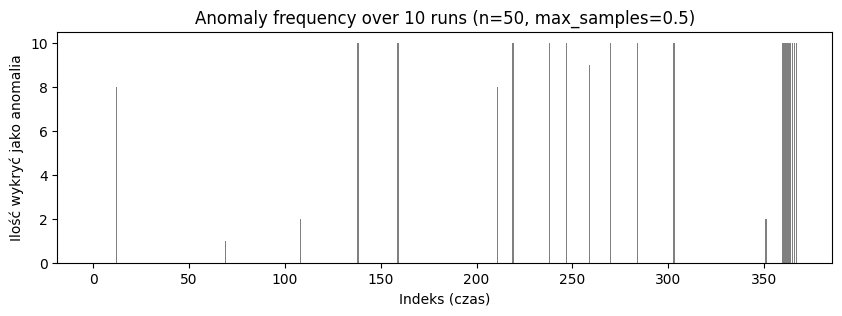

n=50, max_samples=1.0: stabilnie wykrytych = 17


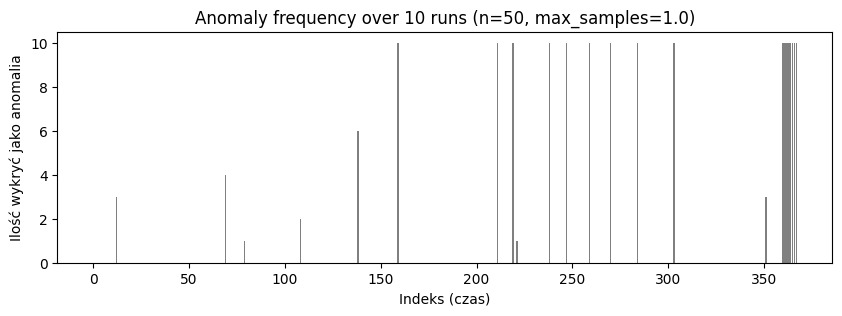

n=100, max_samples=0.5: stabilnie wykrytych = 19


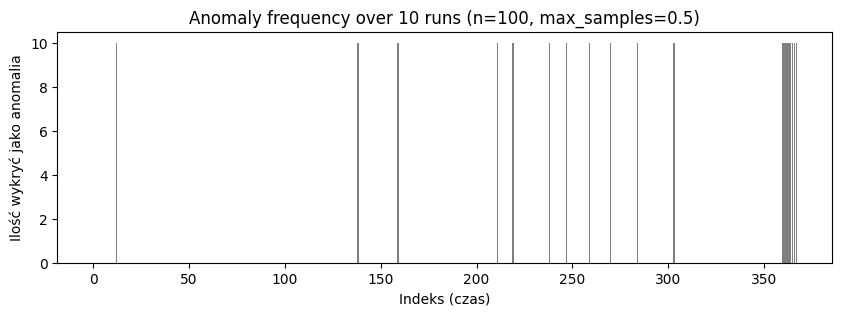

n=100, max_samples=1.0: stabilnie wykrytych = 17


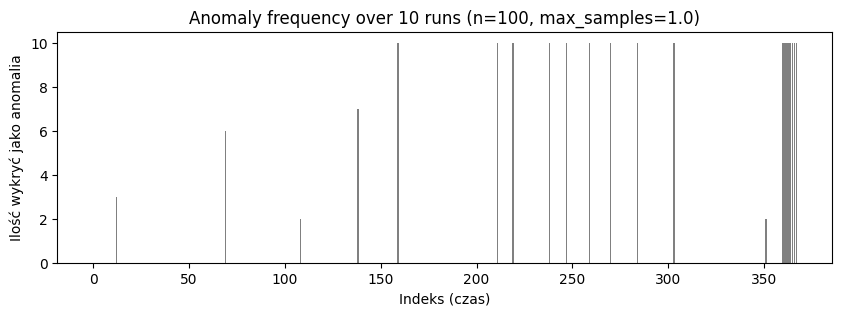

n=200, max_samples=0.5: stabilnie wykrytych = 19


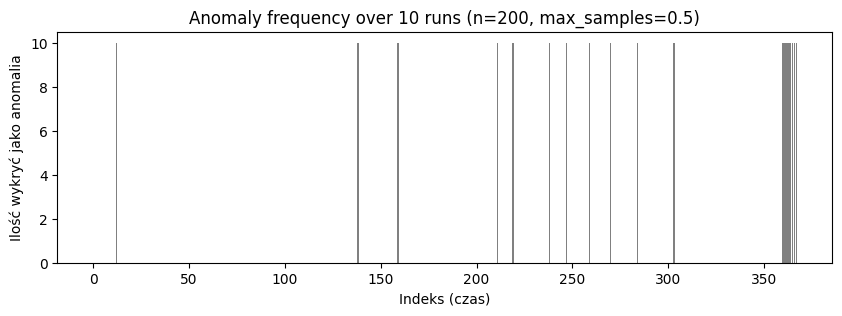

n=200, max_samples=1.0: stabilnie wykrytych = 17


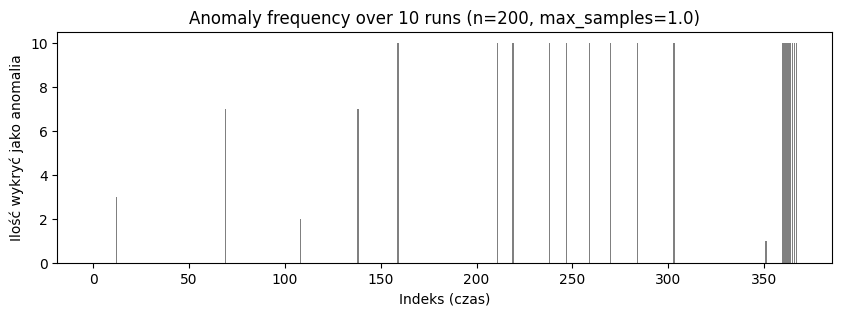

,n_estimators,max_samples,consistent_count
0,50,0.5,16
1,50,1.0,17
2,100,0.5,19
3,100,1.0,17
4,200,0.5,19
5,200,1.0,17


In [33]:
n_estimators_list = [50, 100, 200]
max_samples_list = [0.5, 1.0]
seeds = list(range(10))
stability_summary = {}
for n in n_estimators_list:
    for ms in max_samples_list:
        freq = np.zeros(len(combined), dtype=int)
        for s in seeds:
            iso_s = IsolationForest(n_estimators=n, max_samples=ms, contamination=0.05, random_state=s)
            labels_s = iso_s.fit_predict(X)
            freq += (labels_s == -1)
        stability_summary[(n, ms)] = freq
        consistent_indices = np.where(freq == len(seeds))[0]
        print(f'n={n}, max_samples={ms}: stabilnie wykrytych = {len(consistent_indices)}')
        
        plt.figure(figsize=(10,3))
        plt.bar(np.arange(len(combined)), freq, color='grey')
        plt.title(f'Anomaly frequency over {len(seeds)} runs (n={n}, max_samples={ms})')
        plt.xlabel('Indeks (czas)')
        plt.ylabel('Ilość wykryć jako anomalia')
        plt.show()

summary_rows = []
for (n, ms), freq in stability_summary.items():
    consistent = np.where(freq == len(seeds))[0]
    summary_rows.append({'n_estimators': n, 'max_samples': ms, 'consistent_count': len(consistent)})
import pandas as _pd
_pd.DataFrame(summary_rows)

Wyniki pokazują, że punkty odpowiadające atakowi zawsze były wykrywane jako anomalie. To, czy te same punkty są wykryte, zależy raczej od max_samples (ilości próbek).

## Część: Local Outlier Factor (LOF)

In [47]:
import os
from pathlib import Path
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest

out_dir_lof = Path(os.getcwd()) / 'local_outlier_factor_results'
out_dir_lof.mkdir(exist_ok=True)

# używamy `combined`, `normal_rps`, `ddos_rps` z wcześniejszych komórek
X = combined.reshape(-1, 1)
indices = np.arange(len(combined))

iso = IsolationForest(contamination=0.05, random_state=42)
labels_iso = iso.fit_predict(X)
anomaly_indices_iso = np.where(labels_iso == -1)[0]
print('IF (cont=0.05) — liczba anomalii:', len(anomaly_indices_iso))

IF (cont=0.05) — liczba anomalii: 19


### Eksperyment - wpływ liczby sąsiadów
Algorytm Local Outlier Factor wykrywa anomalie na podstawie lokalnej gęstości danych. Jednym z najważniejszych parametrów jest `n_neighbors`, który określa liczbę sąsiadów branych pod uwagę przy obliczaniu lokalnej gęstości.

Przeprowadzono eksperyment dla wartości `n_neighbors = [5, 10, 20, 50]` z `contamination=0.05`, porównano indeksy wykrytych anomalii i zestawiono wyniki w tabeli.

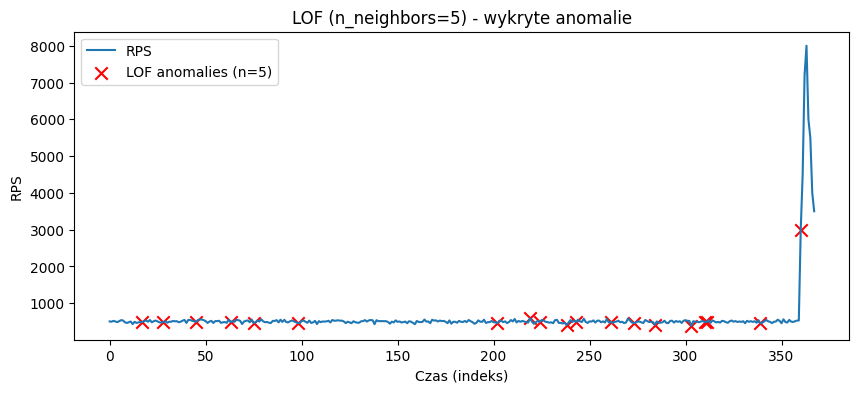

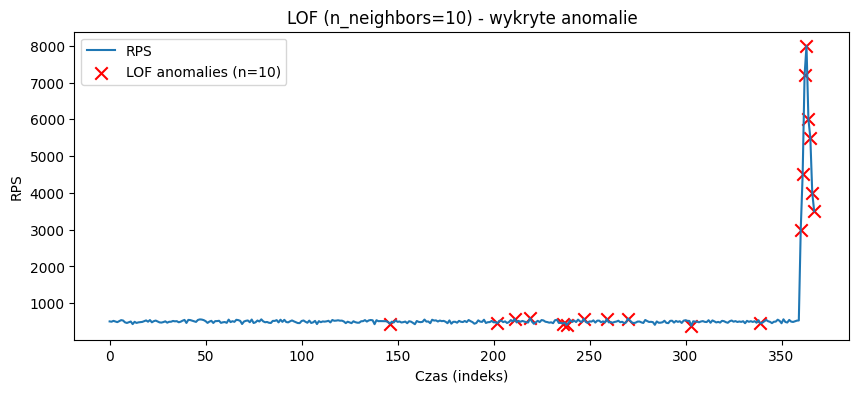

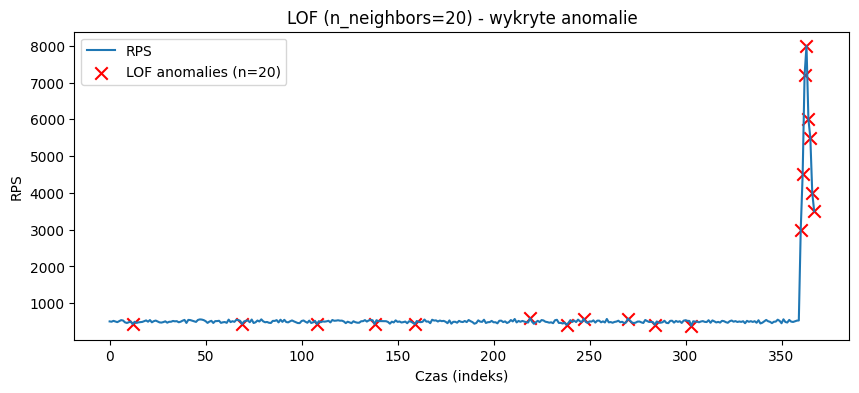

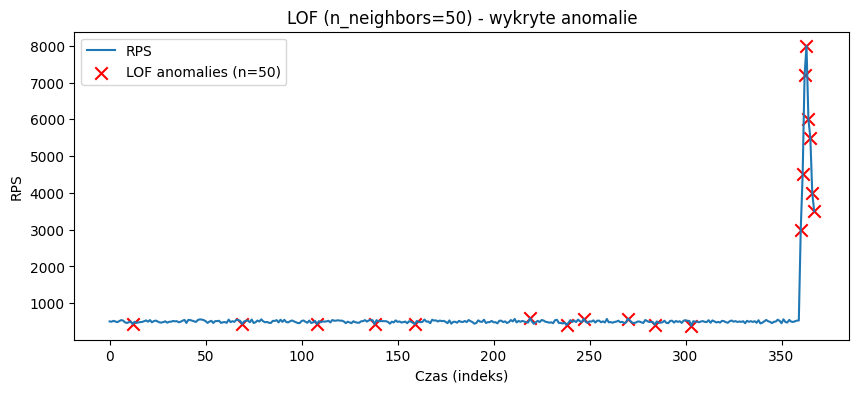

,n_neighbors,anomaly_count,anomaly_indices
0,5,19,17 28 45 63 75 98 202 219 224 238 243 261 273 ...
1,10,19,146 202 211 219 236 238 247 259 270 303 339 36...
2,20,19,12 69 108 138 159 219 238 247 270 284 303 360 ...
3,50,19,12 69 108 138 159 219 238 247 270 284 303 360 ...


In [52]:
n_list = [5, 10, 20, 50]
results = []

for n_neighbors in n_list:
    lof = LocalOutlierFactor(n_neighbors=n_neighbors, contamination=0.05)
    labels_lof = lof.fit_predict(X)  # 1 normal, -1 anomaly
    anomaly_indices_lof = np.where(labels_lof == -1)[0]
    anomaly_values_lof = combined[anomaly_indices_lof]

    plt.figure(figsize=(10,4))
    plt.plot(indices, combined, label='RPS')
    if anomaly_indices_lof.size > 0:
        plt.scatter(anomaly_indices_lof, anomaly_values_lof, color='red', marker='x', s=80, label=f'LOF anomalies (n={n_neighbors})')
    plt.xlabel('Czas (indeks)')
    plt.ylabel('RPS')
    plt.title(f'LOF (n_neighbors={n_neighbors}) - wykryte anomalie')
    plt.legend()
    plt.show()

    results.append({
        'n_neighbors': n_neighbors,
        'anomaly_count': int(anomaly_indices_lof.size),
        'anomaly_indices': ' '.join(map(str, anomaly_indices_lof.tolist())),
    })

df_lof = pd.DataFrame(results)
df_lof

Liczba wykrywanych anomalii pozostaje taka sama dla wszystkich wartości parametru, jednak zmieniają się konkretne indeksy punktów oznaczonych jako anomalie. Dla małych wartości parametru model jest bardziej wrażliwy na lokalne fluktuacje danych. Dla większych wartości `n_neighbors` (20, 50) model uwzględnia większy fragment danych przy ocenie lokalnej gęstości, co powoduje stabilniejsze wykrywanie anomalii (te same indeksy).

## Porównanie indeksów IF vs LOF
Obliczono część wspólną indeksów anomalii wykrytych przez IsolationForest oraz przez LOF dla różnych wartości `n_neighbors`. Poniżej znajdują się wykresy porównawcze, gdzie oznaczono anomalie wykryte przez LOF, IF oraz przez oba algorytmy.

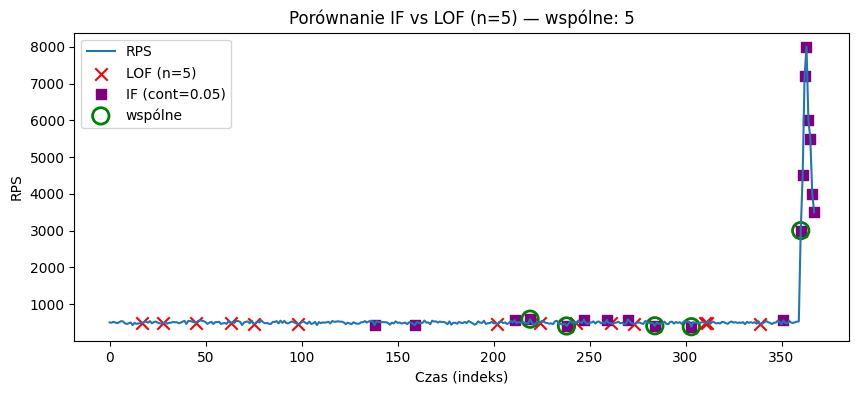

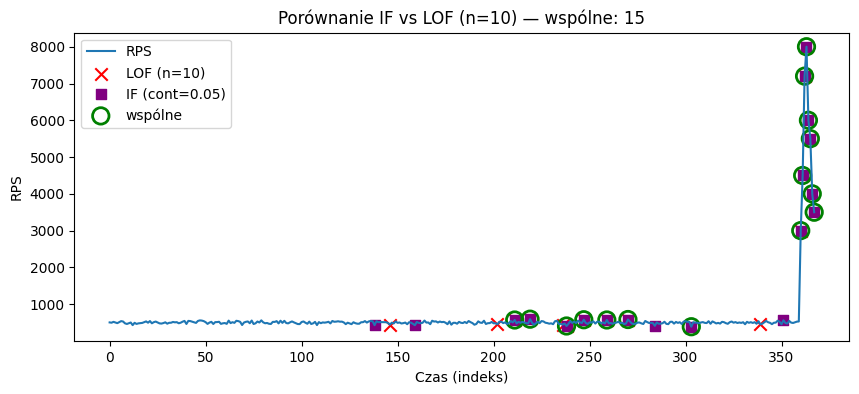

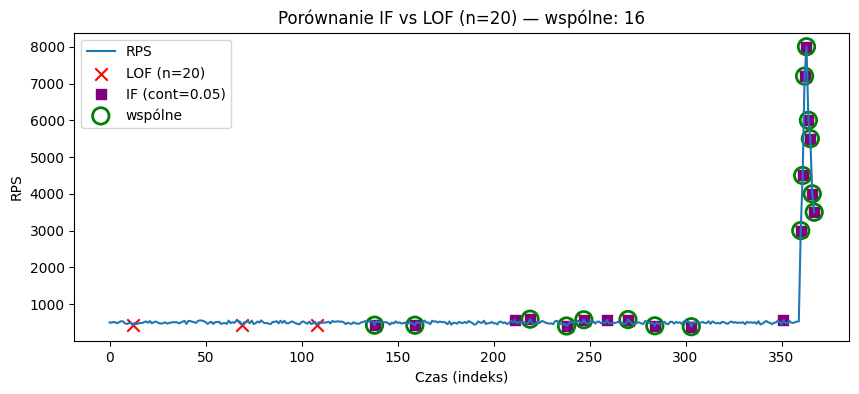

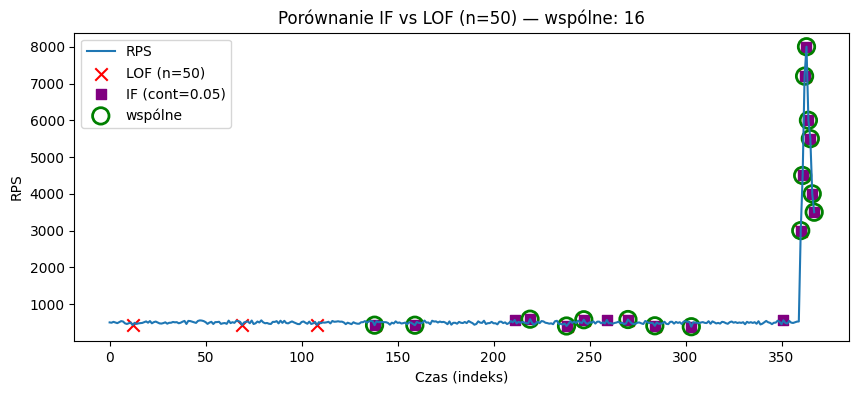

,n_neighbors,lof_count,if_count,common_count,common_indices
0,5,19,19,5,219 238 284 303 360
1,10,19,19,15,211 219 238 247 259 270 303 360 361 362 363 36...
2,20,19,19,16,138 159 219 238 247 270 284 303 360 361 362 36...
3,50,19,19,16,138 159 219 238 247 270 284 303 360 361 362 36...


In [53]:
n_list = [5, 10, 20, 50]
compare_rows = []
for n_neighbors in n_list:
    lof = LocalOutlierFactor(n_neighbors=n_neighbors, contamination=0.05)
    labels_lof = lof.fit_predict(X)
    anomaly_indices_lof = np.where(labels_lof == -1)[0]
    set_lof = set(anomaly_indices_lof)
    set_if = set(anomaly_indices_iso)
    common = sorted(set_lof & set_if)
    compare_rows.append({'n_neighbors': n_neighbors, 'lof_count': len(anomaly_indices_lof), 'if_count': len(anomaly_indices_iso), 'common_count': len(common), 'common_indices': ' '.join(map(str, common))})

    plt.figure(figsize=(10,4))
    plt.plot(indices, combined, label='RPS')
    if anomaly_indices_lof.size > 0:
        plt.scatter(anomaly_indices_lof, combined[anomaly_indices_lof], color='red', marker='x', s=80, label=f'LOF (n={n_neighbors})')
    if anomaly_indices_iso.size > 0:
        plt.scatter(anomaly_indices_iso, combined[anomaly_indices_iso], color='purple', marker='s', s=60, label='IF (cont=0.05)')
    if common:
        plt.scatter(common, combined[common], facecolors='none', edgecolors='green', s=140, linewidths=2, label='wspólne')
    plt.title(f'Porównanie IF vs LOF (n={n_neighbors}) — wspólne: {len(common)}')
    plt.xlabel('Czas (indeks)')
    plt.ylabel('RPS')
    plt.legend()
    plt.show()

df_compare = pd.DataFrame(compare_rows)
df_compare

### Eksperyment - LOF w trybie novelty=True
Algorytm LOF może również pracować w trybie `novelty detection`, w którym model trenowany jest wyłącznie na danych reprezentujących normalne zachowanie systemu. Następnie model stosowany jest do wykrywania anomalii w nowych danych.

W eksperymencie model LOF został wytrenowany na danych normalnych, a następnie użyty do analizy całego sygnału.

LOF novelty - liczba anomalii: 31


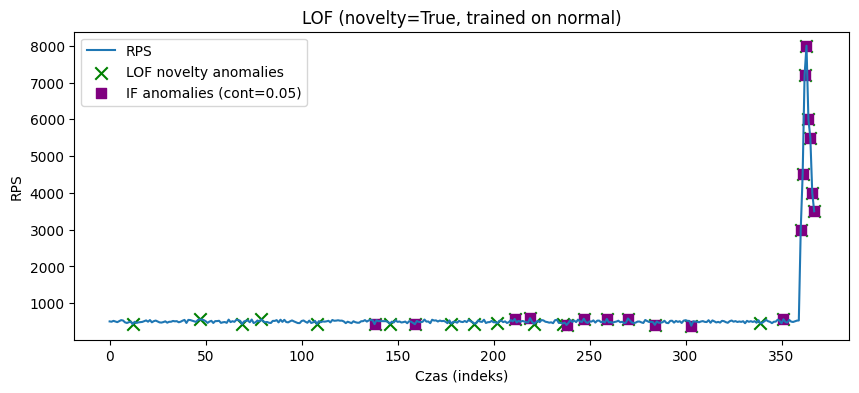

In [54]:
lof_novel = LocalOutlierFactor(n_neighbors=20, contamination='auto', novelty=True)
lof_novel.fit(normal_rps.reshape(-1,1))
pred_novel = lof_novel.predict(X)  # 1 normal, -1 anomaly
anomaly_indices_novel = np.where(pred_novel == -1)[0]
print('LOF novelty - liczba anomalii:', len(anomaly_indices_novel))

plt.figure(figsize=(10,4))
plt.plot(indices, combined, label='RPS')
if anomaly_indices_novel.size > 0:
    plt.scatter(anomaly_indices_novel, combined[anomaly_indices_novel], color='green', marker='x', s=80, label='LOF novelty anomalies')
if anomaly_indices_iso.size > 0:
    plt.scatter(anomaly_indices_iso, combined[anomaly_indices_iso], color='purple', marker='s', s=60, label='IF anomalies (cont=0.05)')
plt.xlabel('Czas (indeks)')
plt.ylabel('RPS')
plt.title('LOF (novelty=True, trained on normal)')
plt.legend()
plt.show()

results.append({
    'n_neighbors': 20,
    'mode': 'novelty',
    'anomaly_count': int(anomaly_indices_novel.size),
    'anomaly_indices': ' '.join(map(str, anomaly_indices_novel.tolist())),
    'common_with_if': ' '.join(map(str, sorted(set(anomaly_indices_novel) & set(anomaly_indices_iso))))
})

W tym przypadku wykryto 31 anomalii.
Większa liczba wykrytych punktów wynika z faktu, że model został wytrenowany wyłącznie na danych normalnych, przez co wszelkie odstępstwa od tego wzorca są częściej oznaczane jako anomalie. Podobnie jak w przypadku Isolation Forest trenowanego na normalnym ruchu, zwiększa to czułość detekcji kosztem większej liczby fałszywych alarmów.

## Dane wielowymiarowe i metryki
W tej sekcji powtórzono eksperymenty z pliku `dane_wielowymiarowe_i_metryki.py` dla trzech konfiguracji danych i przedstawiono metryki (Precision, Recall, F1) dla: `IsolationForest`, `LOF`, `OneClassSVM` - zarówno bez skalowania, jak i po zastosowaniu `StandardScaler`.

Eksperymenty: `base`, `attack_avgbytes_similar`, `imbalance_stronger`.

,experiment,scaled,model,precision,recall,f1
0,base,False,IsolationForest,1.000000,1.00,1.000000
1,base,False,LOF,0.300000,0.30,0.300000
2,base,False,OneClassSVM,0.509804,0.52,0.514851
3,base,True,IsolationForest,1.000000,1.00,1.000000
4,base,True,LOF,0.040000,0.04,0.040000
5,base,True,OneClassSVM,0.673077,0.70,0.686275
6,attack_avgbytes_similar,False,IsolationForest,0.980000,0.98,0.980000
7,attack_avgbytes_similar,False,LOF,0.200000,0.20,0.200000
8,attack_avgbytes_similar,False,OneClassSVM,0.294118,0.30,0.297030
9,attack_avgbytes_similar,True,IsolationForest,0.980000,0.98,0.980000


--- base ---


f1           precision           recall      
scaled              False     True      False     True   False True 
model                                                               
IsolationForest  1.000000  1.000000  1.000000  1.000000   1.00  1.00
LOF              0.300000  0.040000  0.300000  0.040000   0.30  0.04
OneClassSVM      0.514851  0.686275  0.509804  0.673077   0.52  0.70

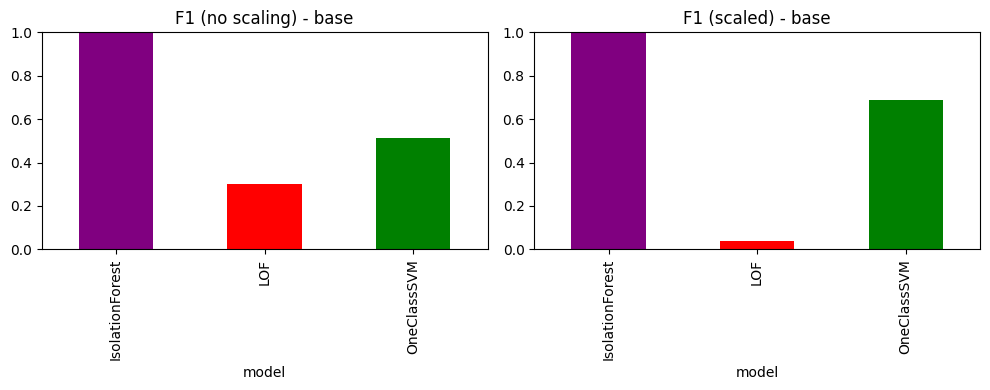

--- attack_avgbytes_similar ---


f1           precision           recall      
scaled             False     True      False     True   False True 
model                                                              
IsolationForest  0.98000  0.980000  0.980000  0.980000   0.98  0.98
LOF              0.20000  0.120000  0.200000  0.120000   0.20  0.12
OneClassSVM      0.29703  0.510204  0.294118  0.520833   0.30  0.50

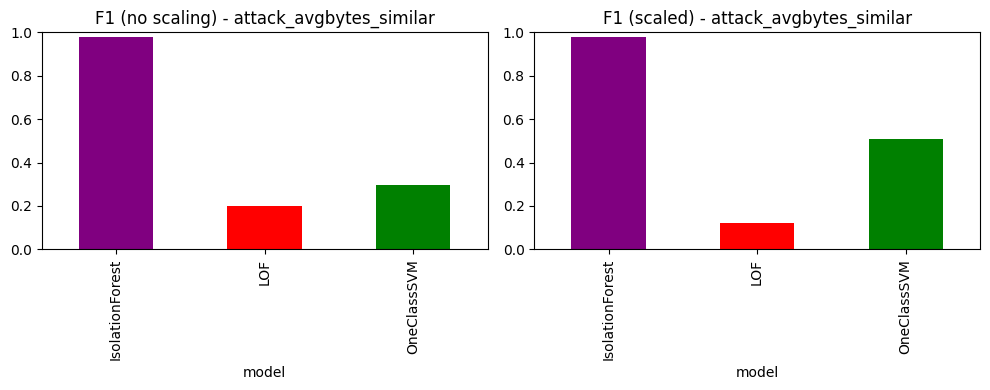

--- imbalance_stronger ---


f1           precision           recall      
scaled              False     True      False     True   False True 
model                                                               
IsolationForest  1.000000  1.000000  1.000000  1.000000    1.0   1.0
LOF              1.000000  1.000000  1.000000  1.000000    1.0   1.0
OneClassSVM      0.526316  0.727273  0.555556  0.666667    0.5   0.8

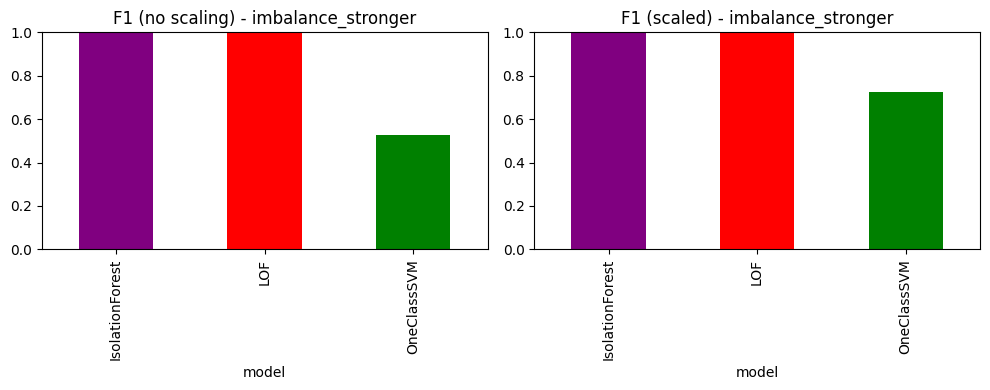

In [57]:
from dane_wielowymiarowe_i_metryki import build_dataset, eval_models, experiments
import pandas as pd
from sklearn.preprocessing import StandardScaler

rows = []
for name, n_normal, n_attack, avg_bytes_loc, err_low, err_high in experiments:
    X, y = build_dataset(n_normal=n_normal, n_attack=n_attack, attack_avg_bytes_loc=avg_bytes_loc, attack_error_low=err_low, attack_error_high=err_high)
    res = eval_models(X, y)
    iso_p, iso_r, iso_f1 = res['iso_scores']
    lof_p, lof_r, lof_f1 = res['lof_scores']
    svm_p, svm_r, svm_f1 = res['svm_scores']
    rows.append({'experiment': name, 'scaled': False, 'model': 'IsolationForest', 'precision': iso_p, 'recall': iso_r, 'f1': iso_f1})
    rows.append({'experiment': name, 'scaled': False, 'model': 'LOF', 'precision': lof_p, 'recall': lof_r, 'f1': lof_f1})
    rows.append({'experiment': name, 'scaled': False, 'model': 'OneClassSVM', 'precision': svm_p, 'recall': svm_r, 'f1': svm_f1})

    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    res_s = eval_models(Xs, y)
    iso_p_s, iso_r_s, iso_f1_s = res_s['iso_scores']
    lof_p_s, lof_r_s, lof_f1_s = res_s['lof_scores']
    svm_p_s, svm_r_s, svm_f1_s = res_s['svm_scores']
    rows.append({'experiment': name, 'scaled': True, 'model': 'IsolationForest', 'precision': iso_p_s, 'recall': iso_r_s, 'f1': iso_f1_s})
    rows.append({'experiment': name, 'scaled': True, 'model': 'LOF', 'precision': lof_p_s, 'recall': lof_r_s, 'f1': lof_f1_s})
    rows.append({'experiment': name, 'scaled': True, 'model': 'OneClassSVM', 'precision': svm_p_s, 'recall': svm_r_s, 'f1': svm_f1_s})

df_multi = pd.DataFrame(rows)
display(df_multi)

for exp in df_multi['experiment'].unique():
    print('---', exp, '---')
    display(df_multi[df_multi['experiment']==exp].pivot_table(index='model', columns='scaled', values=['precision','recall','f1']))
    
    sub = df_multi[df_multi['experiment']==exp]
    no = sub[sub['scaled']==False].set_index('model')
    yes = sub[sub['scaled']==True].set_index('model')
    fig, ax = plt.subplots(1,2, figsize=(10,4))
    no['f1'].plot(kind='bar', ax=ax[0], color=['purple','red','green'], ylim=(0,1), title=f'F1 (no scaling) - {exp}')
    yes['f1'].plot(kind='bar', ax=ax[1], color=['purple','red','green'], ylim=(0,1), title=f'F1 (scaled) - {exp}')
    plt.tight_layout()
    plt.show()

#### Omówienie eksperymentów

### Eksperyment - wpływ standaryzacji cech
W pierwszym eksperymencie sprawdzono wpływ standaryzacji danych przy użyciu `StandardScaler`. Standaryzacja przekształca każdą cechę tak, aby miała średnią równą 0 oraz odchylenie standardowe równe 1.

Wnioski: Isolation Forest osiąga bardzo dobre wyniki niezależnie od skalowania, co wynika z faktu, że metoda bazuje na losowych podziałach przestrzeni cech i jest stosunkowo odporna na różnice skali. Dla LOF standaryzacja pogorszyła wyniki - zmiana skali wpływa bezpośrednio na odległości między punktami, od których zależy LOF. One-Class SVM zyskuje na standaryzacji, ponieważ opiera się na funkcjach jądra i jest wrażliwy na skalę cech.

### Eksperyment - zmiana rozkładów cech ataku
W drugim eksperymencie zmniejszono różnicę między ruchem normalnym a atakiem poprzez ustawienie `avg_bytes_att` na wartości bliższe normalnemu ruchowi oraz zmniejszenie `error_rate_att` do zakresu 0.02-0.05. W efekcie sygnał ataku stał się trudniejszy do odróżnienia od ruchu normalnego.

Wnioski: Zmniejszenie różnicy między ruchem normalnym a atakiem pogarsza skuteczność metod opartych na gęstości i odległościach (LOF, One-Class SVM). Isolation Forest nadal wykrywa anomalie skutecznie, ponieważ potrafi izolować odstające punkty w wielowymiarowej przestrzeni cech.

### Eksperyment - silna nierównowaga klas
W trzecim eksperymencie zwiększono nierównowagę klas (1000 próbek normalnych vs 10 próbek ataku), aby sprawdzić wpływ skrajnej nierównowagi na metryki.

Wnioski: W scenariuszu bardzo silnej nierównowagi klas zarówno Isolation Forest, jak i LOF mogą poprawnie wykrywać punkty ataku, jeśli wartości generowane dla ataku są wyraźnie odstające od normalnych. Model One-Class SVM radzi sobie gorzej w scenariuszu silnej nierównowagi klas, co może wynikać z trudności w odpowiednim dopasowaniu granicy decyzyjnej przy bardzo małej liczbie przykładów anomalii.

## Część: Logi Nginx / Wireshark — parsowanie i budowa cech

Użyto kodu z `symulowane_logi_nginx.py`. Zbudowano macierz cech zawierającą :

- `rps` - liczba zapytań na minutę
- `unique_ips` - liczba unikalnych IP w oknie
- `avg_size` - średni rozmiar odpowiedzi
- `error_rate` - udział odpowiedzi o statusie >= 400
- `post_count` - liczba żądań POST
- `unique_paths` - liczba różnych ścieżek
- `bot_fraction` - odsetek żądań od botów (UA zawiera 'bot')
- `max_requests_from_one_ip` - maksymalna liczba żądań z jednego IP w oknie
- `num_ips_over_threshold` - liczba IP z liczbą zapytań powyżej progu (parametr `ip_freq_threshold`)

Poniżej uruchamiono przykład na danych symulowanych. Ukazano macierz cech, statystyki oraz wykresy czasowe z oznaczeniem anomalii wykrytych przez `IsolationForest`.


,rps,unique_ips,avg_size,error_rate,post_count,unique_paths,bot_fraction,max_requests_from_one_ip,num_ips_over_threshold
2025-01-01 10:00,4.0,4.0,1926.5,0.0,2.0,4.0,0.0,1.0,0.0
2025-01-01 10:01,1.0,1.0,120.0,1.0,1.0,1.0,0.0,1.0,0.0
2025-01-01 10:02,1.0,1.0,2048.0,0.0,0.0,1.0,1.0,1.0,0.0
2025-01-01 10:05,1.0,1.0,256.0,1.0,0.0,1.0,1.0,1.0,0.0
2025-01-01 10:10,6.0,6.0,850.0,0.0,0.0,6.0,0.0,1.0,0.0
2025-01-01 10:11,6.0,6.0,850.0,0.0,0.0,6.0,0.0,1.0,0.0
2025-01-01 10:12,6.0,6.0,850.0,0.0,0.0,6.0,0.0,1.0,0.0
2025-01-01 10:13,6.0,6.0,850.0,0.0,0.0,6.0,0.0,1.0,0.0
2025-01-01 10:14,6.0,6.0,850.0,0.0,0.0,6.0,0.0,1.0,0.0
2025-01-01 10:20,30.0,1.0,1200.0,0.0,0.0,1.0,1.0,30.0,1.0


,rps,unique_ips,avg_size,error_rate,post_count,unique_paths,bot_fraction,max_requests_from_one_ip,num_ips_over_threshold
count,10.00000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,6.70000,3.800000,980.050000,0.200000,0.300000,3.800000,0.300000,3.900000,0.100000
std,8.49902,2.485514,617.626481,0.421637,0.674949,2.485514,0.483046,9.170605,0.316228
min,1.00000,1.000000,120.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,1.75000,1.000000,850.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
50%,6.00000,5.000000,850.000000,0.000000,0.000000,5.000000,0.000000,1.000000,0.000000
75%,6.00000,6.000000,1112.500000,0.000000,0.000000,6.000000,0.750000,1.000000,0.000000
max,30.00000,6.000000,2048.000000,1.000000,2.000000,6.000000,1.000000,30.000000,1.000000


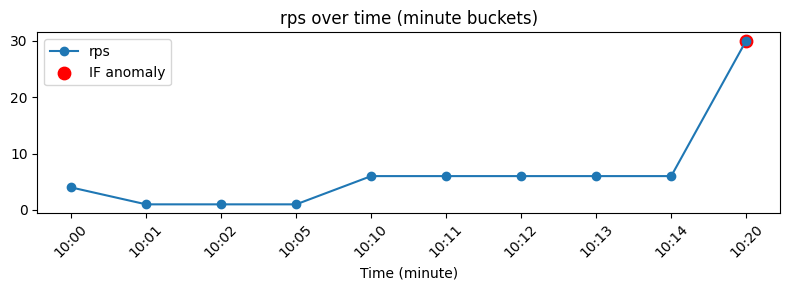

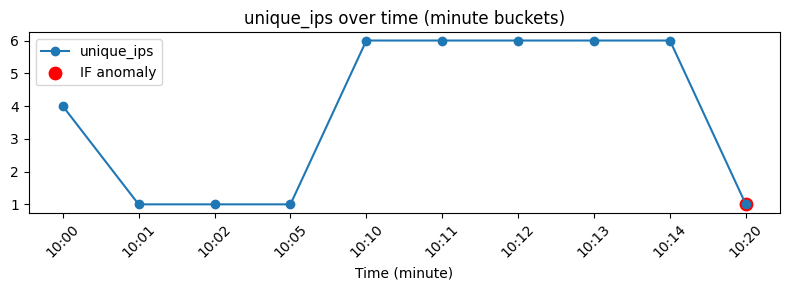

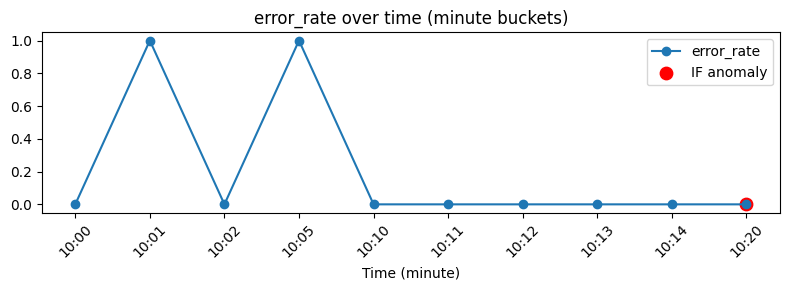

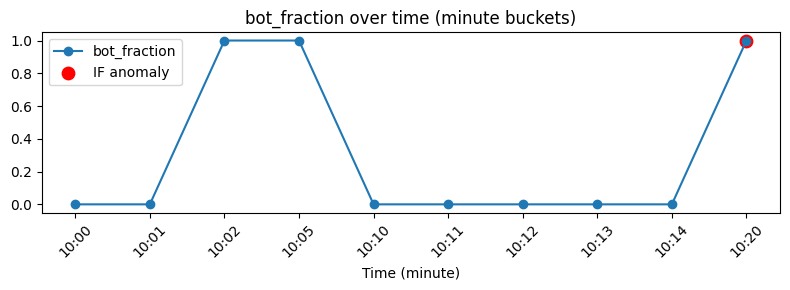

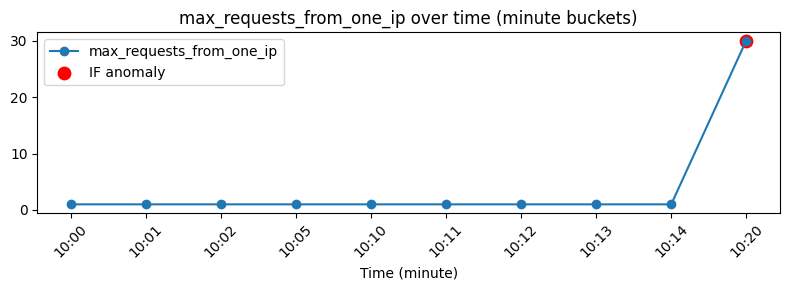

In [58]:
from symulowane_logi_nginx import build_features_from_logs, fake_logs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

X, feature_names, times, global_ip_counter = build_features_from_logs(fake_logs, ip_freq_threshold=10)

index = [t.strftime('%Y-%m-%d %H:%M') for t in times]
df_features = pd.DataFrame(X, columns=feature_names, index=index)

display(df_features)

display(df_features.describe())

iso = IsolationForest(contamination=0.05, random_state=42)
labels = iso.fit_predict(X)
anomaly_idx = np.where(labels == -1)[0]

times_str = [t.strftime('%H:%M') for t in times]
plots = [('rps', 0), ('unique_ips', 1), ('error_rate', 3), ('bot_fraction', 6), ('max_requests_from_one_ip', 7)]
for name, idx in plots:
    plt.figure(figsize=(8,3))
    plt.plot(times_str, X[:, idx], marker='o', label=name)
    if anomaly_idx.size > 0:
        plt.scatter([times_str[i] for i in anomaly_idx], X[anomaly_idx, idx], color='red', s=80, label='IF anomaly')
    plt.xticks(rotation=45)
    plt.xlabel('Time (minute)')
    plt.title(f'{name} over time (minute buckets)')
    plt.legend()
    plt.tight_layout()
    plt.show()


### Czy cechy reagują zgodnie z oczekiwaniami?

Tak, ponieważ:
- RPS: wystąpił wyraźny skok w minutowych bucketach odpowiadających atakowi.
- unique_ips: rośnie, gdy sygnały pochodzą z wielu adresów; jeśli sygnał pochodzi z jednego IP, wartość ta pozostanie niska lub nieznacznie zmaleje (wskazuje na atak DDoS).
- error_rate: wzrasta, gdy serwer zwraca kody >=400 (np. 503) w czasie obciążenia lub błędów.
Dodatkowo:
- bot_fraction i max_requests_from_one_ip: bot_fraction rośnie przy widocznych UA zawierających "bot"; max_requests_from_one_ip rośnie przy atakach z pojedynczych, intensywnych źródeł.
- num_ips_over_threshold: zwiększa się, gdy wiele adresów przekracza próg zapytań (w tym przypadku 10) w tym samym oknie.